In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2026-05-14 07:19:46.847072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778743187.092356      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778743187.154691      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778743187.693059      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778743187.693105      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778743187.693108      57 computation_placer.cc:177] computation placer alr

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


VOCAB_SIZE    = 10000
MAX_LENGTH    = 300
EMBEDDING_DIM = 128
BATCH_SIZE    = 64
EPOCHS        = 20
FILTER_SIZES  = [2, 3, 4, 5]
NUM_FILTERS   = 128
DROPOUT_RATE  = 0.5
DATA_PATH     = '/kaggle/input/datasets/cjpuertollano/semicleaned-withrating/SEMI-CLEANED(with Rating)_dataset.csv'

CLASS_NAMES = ['CG', 'OR']

In [ ]:
try:
    df = pd.read_csv(DATA_PATH, usecols=['Rating', 'Label', 'Review'])
except FileNotFoundError:
    print("File not found — using synthetic demo data.")
    df = pd.DataFrame({
        'Rating': np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0], 5000),
        'Label':  np.random.choice([0, 1], 5000),
        'Review': [f"Sample review text number {i}" for i in range(5000)]
    })

required_cols = {'Review', 'Label', 'Rating'}
assert required_cols.issubset(df.columns), \
    f"Missing columns: {required_cols - set(df.columns)}"

texts  = df['Review'].astype(str).values
labels = df['Label'].values

or_count  = (labels == 1).sum()
total     = len(labels)
print(f"\n── CLASS DISTRIBUTION ──────────────────────────────────────")
print(f"  Label 0 | Computer-Generated : {cg_count:>6} ({cg_count/total*100:.1f}%)")
print(f"  Label 1 | Original Review    : {or_count:>6} ({or_count/total*100:.1f}%)")
ratio = max(cg_count, or_count) / min(cg_count, or_count)
print(f"  Imbalance ratio              : {ratio:.2f}x")
if ratio > 1.5:
    print(f"  ⚠️  Significant imbalance detected — class weights will be applied.")
else:
    print(f"  ✅  Classes are roughly balanced.")
print(f"────────────────────────────────────────────────────────────\n")


── CLASS DISTRIBUTION ──────────────────────────────────────
  Label 0 | Computer-Generated :  20215 (50.0%)
  Label 1 | Original Review    :  20190 (50.0%)
  Imbalance ratio              : 1.00x
  ✅  Classes are roughly balanced.
────────────────────────────────────────────────────────────



In [ ]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
print(f"Vocab size: {len(tokenizer.word_index)} | Padded shape: {X.shape}")

Vocab size: 48730 | Padded shape: (40405, 300)


In [ ]:
y = labels.astype(np.int32)
print(f"Label dtype: {y.dtype} | Unique values: {np.unique(y)}")

Label dtype: int32 | Unique values: [0 1]


In [ ]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Split → Train: 32324 | Val: 4040 | Test: 4041


In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\n── CLASS WEIGHTS (applied during training) ──────────────────")
for idx, w in class_weight_dict.items():
    print(f"  Label {idx} | {CLASS_NAMES[idx]:<22} : {w:.4f}")
print(f"────────────────────────────────────────────────────────────\n")


── CLASS WEIGHTS (applied during training) ──────────────────
  Label 0 | CG                     : 0.9994
  Label 1 | OR                     : 1.0006
────────────────────────────────────────────────────────────



In [ ]:
def build_multichannel_cnn():
    inp = layers.Input(shape=(MAX_LENGTH,), name="input")


    static_emb = layers.Embedding(
        VOCAB_SIZE, EMBEDDING_DIM,
        trainable=False,
        name="static_embedding"
    )(inp)
    static_emb = layers.SpatialDropout1D(0.2)(static_emb)


    trainable_emb = layers.Embedding(
        VOCAB_SIZE, EMBEDDING_DIM,
        trainable=True,
        name="trainable_embedding"
    )(inp)
    trainable_emb = layers.SpatialDropout1D(0.2)(trainable_emb)


    pooled = []
    for emb, tag in [(static_emb, "static"), (trainable_emb, "trainable")]:
        for fs in FILTER_SIZES:
            x = layers.Conv1D(NUM_FILTERS, fs, activation='relu',
                              padding='same', name=f"conv_{tag}_fs{fs}")(emb)
            x = layers.BatchNormalization()(x)
            x = layers.GlobalMaxPooling1D(name=f"pool_{tag}_fs{fs}")(x)
            pooled.append(x)


    merged = layers.concatenate(pooled, name="concat")

    x = layers.Dense(256, activation='relu')(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name="output")(x)

    return models.Model(inputs=inp, outputs=out)

model = build_multichannel_cnn()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

I0000 00:00:1778743223.071189      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778743223.077387      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_embedding    │ (None, 300, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_embedding │ (None, 300, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 300, 128)  │          0 │ static_embedding… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 300, 128)  │          0 │ trainable_embedd… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs2     │ (None, 300, 128)  │     32,896 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs3     │ (None, 300, 128)  │     49,280 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs4     │ (None, 300, 128)  │     65,664 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs5     │ (None, 300, 128)  │     82,048 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs2  │ (None, 300, 128)  │     32,896 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs3  │ (None, 300, 128)  │     49,280 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs4  │ (None, 300, 128)  │     65,664 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs5  │ (None, 300, 128)  │     82,048 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 128)  │        512 │ conv_static_fs2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv_static_fs3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv_static_fs4[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv_static_fs5[… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 3,320,833 (12.67 MB)

 Trainable params: 2,038,017 (7.77 MB)

 Non-trainable params: 1,282,816 (4.89 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
]


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/20


I0000 00:00:1778743231.641477     140 service.cc:152] XLA service 0x79cd140051b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778743231.641542     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778743231.641551     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778743232.999043     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/506 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.4564 - loss: 1.0036 - precision: 0.4113 - recall: 0.4262  

I0000 00:00:1778743239.480539     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6702 - loss: 0.6636 - precision: 0.6659 - recall: 0.6833

506/506 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.6704 - loss: 0.6633 - precision: 0.6661 - recall: 0.6835 - val_accuracy: 0.5015 - val_loss: 0.7900 - val_precision: 0.5006 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8419 - loss: 0.3607 - precision: 0.8363 - recall: 0.8512

506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8420 - loss: 0.3606 - precision: 0.8364 - recall: 0.8512 - val_accuracy: 0.8832 - val_loss: 0.2616 - val_precision: 0.8341 - val_recall: 0.9564 - learning_rate: 1.0000e-04
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8865 - loss: 0.2714 - precision: 0.8868 - recall: 0.8866 - val_accuracy: 0.8681 - val_loss: 0.2851 - val_precision: 0.8003 - val_recall: 0.9807 - learning_rate: 1.0000e-04
Epoch 4/20
504/506 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9084 - loss: 0.2141 - precision: 0.9089 - recall: 0.9083
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9085 - loss: 0.2140 - precision: 0.9090 - recall: 0.9084 - val_accuracy: 0.8228 - val_loss: 0.3745 - val_precision: 0.7421 - val_recall: 0.9891 - learning_rate: 1.0000e-04
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9307 - loss: 0.1712 - precision: 

506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9396 - loss: 0.1531 - precision: 0.9389 - recall: 0.9407 - val_accuracy: 0.8879 - val_loss: 0.2600 - val_precision: 0.8252 - val_recall: 0.9842 - learning_rate: 4.0000e-06
Epoch 8/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9426 - loss: 0.1471 - precision: 0.9419 - recall: 0.9437

506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9426 - loss: 0.1471 - precision: 0.9419 - recall: 0.9437 - val_accuracy: 0.8889 - val_loss: 0.2576 - val_precision: 0.8265 - val_recall: 0.9842 - learning_rate: 4.0000e-06
Epoch 9/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9378 - loss: 0.1547 - precision: 0.9387 - recall: 0.9369 - val_accuracy: 0.8886 - val_loss: 0.2560 - val_precision: 0.8262 - val_recall: 0.9842 - learning_rate: 4.0000e-06
Epoch 10/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9429 - loss: 0.1431 - precision: 0.9430 - recall: 0.9430 - val_accuracy: 0.8876 - val_loss: 0.2599 - val_precision: 0.8251 - val_recall: 0.9837 - learning_rate: 4.0000e-06
Epoch 11/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9391 - loss: 0.1467 - precision: 0.9382 - recall: 0.9405

506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9391 - loss: 0.1467 - precision: 0.9382 - recall: 0.9405 - val_accuracy: 0.8911 - val_loss: 0.2500 - val_precision: 0.8302 - val_recall: 0.9832 - learning_rate: 4.0000e-06
Epoch 12/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9449 - loss: 0.1393 - precision: 0.9434 - recall: 0.9469 - val_accuracy: 0.8894 - val_loss: 0.2549 - val_precision: 0.8275 - val_recall: 0.9837 - learning_rate: 4.0000e-06
Epoch 13/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9459 - loss: 0.1368 - precision: 0.9471 - recall: 0.9447
Epoch 13: ReduceLROnPlateau reducing learning rate to 1e-06.
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9459 - loss: 0.1368 - precision: 0.9471 - recall: 0.9447 - val_accuracy: 0.8886 - val_loss: 0.2569 - val_precision: 0.8265 - val_recall: 0.9837 - learning_rate: 4.0000e-06
Epoch 14/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9460 - loss: 0.1371 - precision: 0.9475 - reca

In [ ]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-7)

y_pred = (model.predict(X_test, verbose=0).flatten() > 0.5).astype(int)

print("\n── TEST RESULTS ──────────────────────────────────────────")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall   : {test_rec:.4f}")
print(f"  F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

pred_cg = (y_pred == 0).sum()
pred_or = (y_pred == 1).sum()
print(f"── PREDICTION DISTRIBUTION (test set) ──────────────────────")
print(f"  Predicted Computer-Generated : {pred_cg} ({pred_cg/len(y_pred)*100:.1f}%)")
print(f"  Predicted Original Review    : {pred_or} ({pred_or/len(y_pred)*100:.1f}%)")
if pred_cg == 0:
    print("  ❌ Model predicted ZERO CG samples — class imbalance not fully resolved.")
elif pred_or == 0:
    print("  ❌ Model predicted ZERO OR samples — something else is wrong.")
else:
    print("  ✅ Model is predicting both classes.")
print(f"────────────────────────────────────────────────────────────\n")


── TEST RESULTS ──────────────────────────────────────────
  Accuracy : 0.8931
  Precision: 0.8291
  Recall   : 0.9901
  F1-Score : 0.9025

Classification Report:
              precision    recall  f1-score   support

          CG       0.99      0.80      0.88      2022
          OR       0.83      0.99      0.90      2019

    accuracy                           0.89      4041
   macro avg       0.91      0.89      0.89      4041
weighted avg       0.91      0.89      0.89      4041

── PREDICTION DISTRIBUTION (test set) ──────────────────────
  Predicted Computer-Generated : 1630 (40.3%)
  Predicted Original Review    : 2411 (59.7%)
  ✅ Model is predicting both classes.
────────────────────────────────────────────────────────────



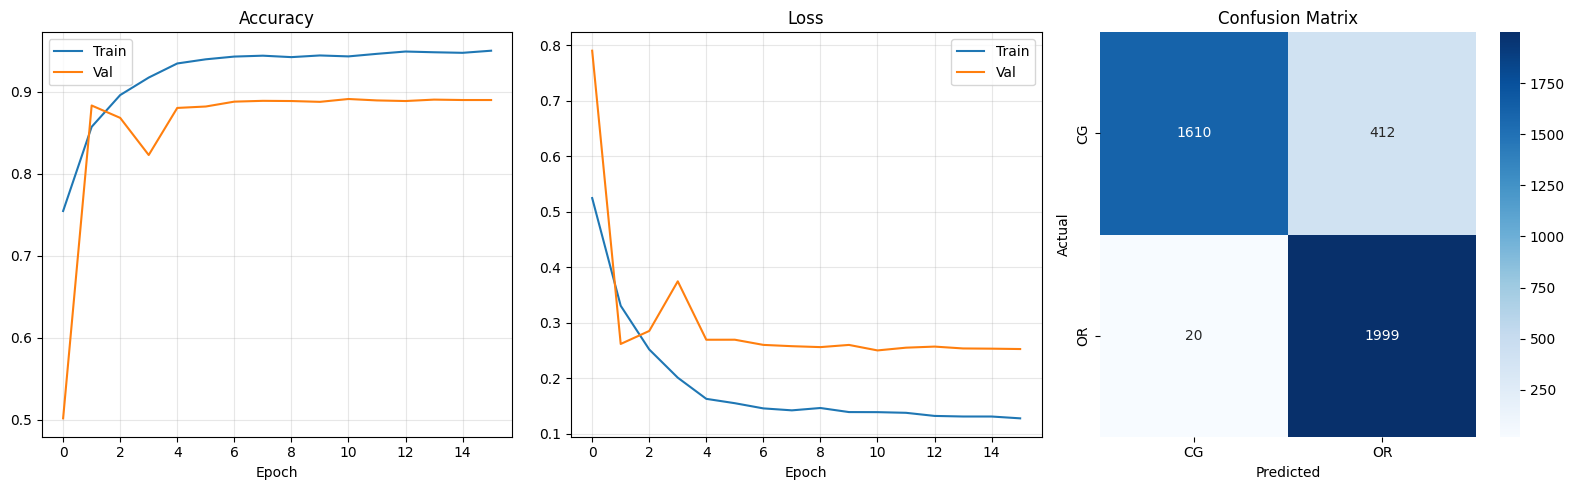

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def predict_review(text):
    """
    pred_prob = P(Original Review) from sigmoid output.
      > 0.5  →  Original Review    (label 1)
      ≤ 0.5  →  Computer-Generated (label 0)
    """
    seq    = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    pred_prob  = model.predict(padded, verbose=0)[0][0]
    class_idx  = 1 if pred_prob > 0.5 else 0
    label      = CLASS_NAMES[class_idx]
    confidence = float(pred_prob) if class_idx == 1 else float(1 - pred_prob)

    if confidence > 0.90:
        level = "Very High"
    elif confidence > 0.75:
        level = "High"
    else:
        level = "Moderate"

    return {
        'label':      label,
        'confidence': confidence,
        'level':      level,
        'raw_score':  float(pred_prob)
    }


print("\n" + "=" * 60)
print("         🔍 AI vs. HUMAN REVIEW DETECTOR")
print("=" * 60)
print("Instructions: Enter a product review below to analyze its origin.")
print("Type 'quit' or 'exit' to stop.\n")

while True:
    print("─" * 60)
    user_input = input("📝 ENTER REVIEW: ").strip()

    if user_input.lower() in ['quit', 'exit']:
        print("👋 Goodbye!")
        break

    if len(user_input) < 5:
        print("⚠️  Review is too short for a reliable analysis.")
        continue

    res = predict_review(user_input)

    filled = "■" * int(res['confidence'] * 20)
    empty  = "□" * (20 - len(filled))

    print(f"\nRESULT    : {res['label'].upper()}")
    print(f"CONFIDENCE: [{filled}{empty}] {res['confidence'] * 100:.1f}% ({res['level']})")


    if res['label'] == CLASS_NAMES[0]:
        print("⚠️  Warning: This text shows patterns typical of AI generation.")
    else:
        print("✅  This review appears to be written by a human.")


         🔍 AI vs. HUMAN REVIEW DETECTOR
Instructions: Enter a product review below to analyze its origin.
Type 'quit' or 'exit' to stop.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance. 



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■■□□□□] 81.0% (High)
✅  This review appears to be written by a human.
────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  This item arrived in excellent condition, the packaging was secure and the delivery was good. 



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■□□□□□] 75.9% (High)
✅  This review appears to be written by a human.
────────────────────────────────────────────────────────────


...

📝 ENTER REVIEW:  So far so good, I had a bit of trouble setting it up at first but I figured it out after watching a video. 



RESULT    : CG
CONFIDENCE: [■■■■■■■■■■■■■□□□□□□□] 69.4% (Moderate)
⚠️  Warning: This text shows patterns typical of AI generation.
────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  Honestly, it’s okay for the price I don't think it’s the best out there but it gets the job done for me.



RESULT    : CG
CONFIDENCE: [■■■■■■■■■■■■■■■■■■□□] 92.0% (Very High)
⚠️  Warning: This text shows patterns typical of AI generation.
────────────────────────────────────────────────────────────


KeyboardInterrupt: Interrupted by user